In [1]:
# Project setup
import sys
import os

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [21]:
from pathlib import Path
import pandas as pd
import numpy as np

from src.data.loaders import PointsDataset
from src.visualization.visualization_utils import create_meshgrid
from src.visualization.feature_space_plots import PlotManager, plot_in_rectangular_coordinates
from src.data.synthetic import generate_uniform_ring_points, generate_uniform_ring_synthetic_dataset, generate_custom_polar_dataset
from src.features.transformations import cartesian_to_polar, polar_to_curvilinear_cos2theta

In [3]:
current_dir = Path.cwd()

# Load the dataset
data_path = current_dir.parent / "data" / "raw" / "points.json"
dataset = PointsDataset.from_json(data_path=data_path)

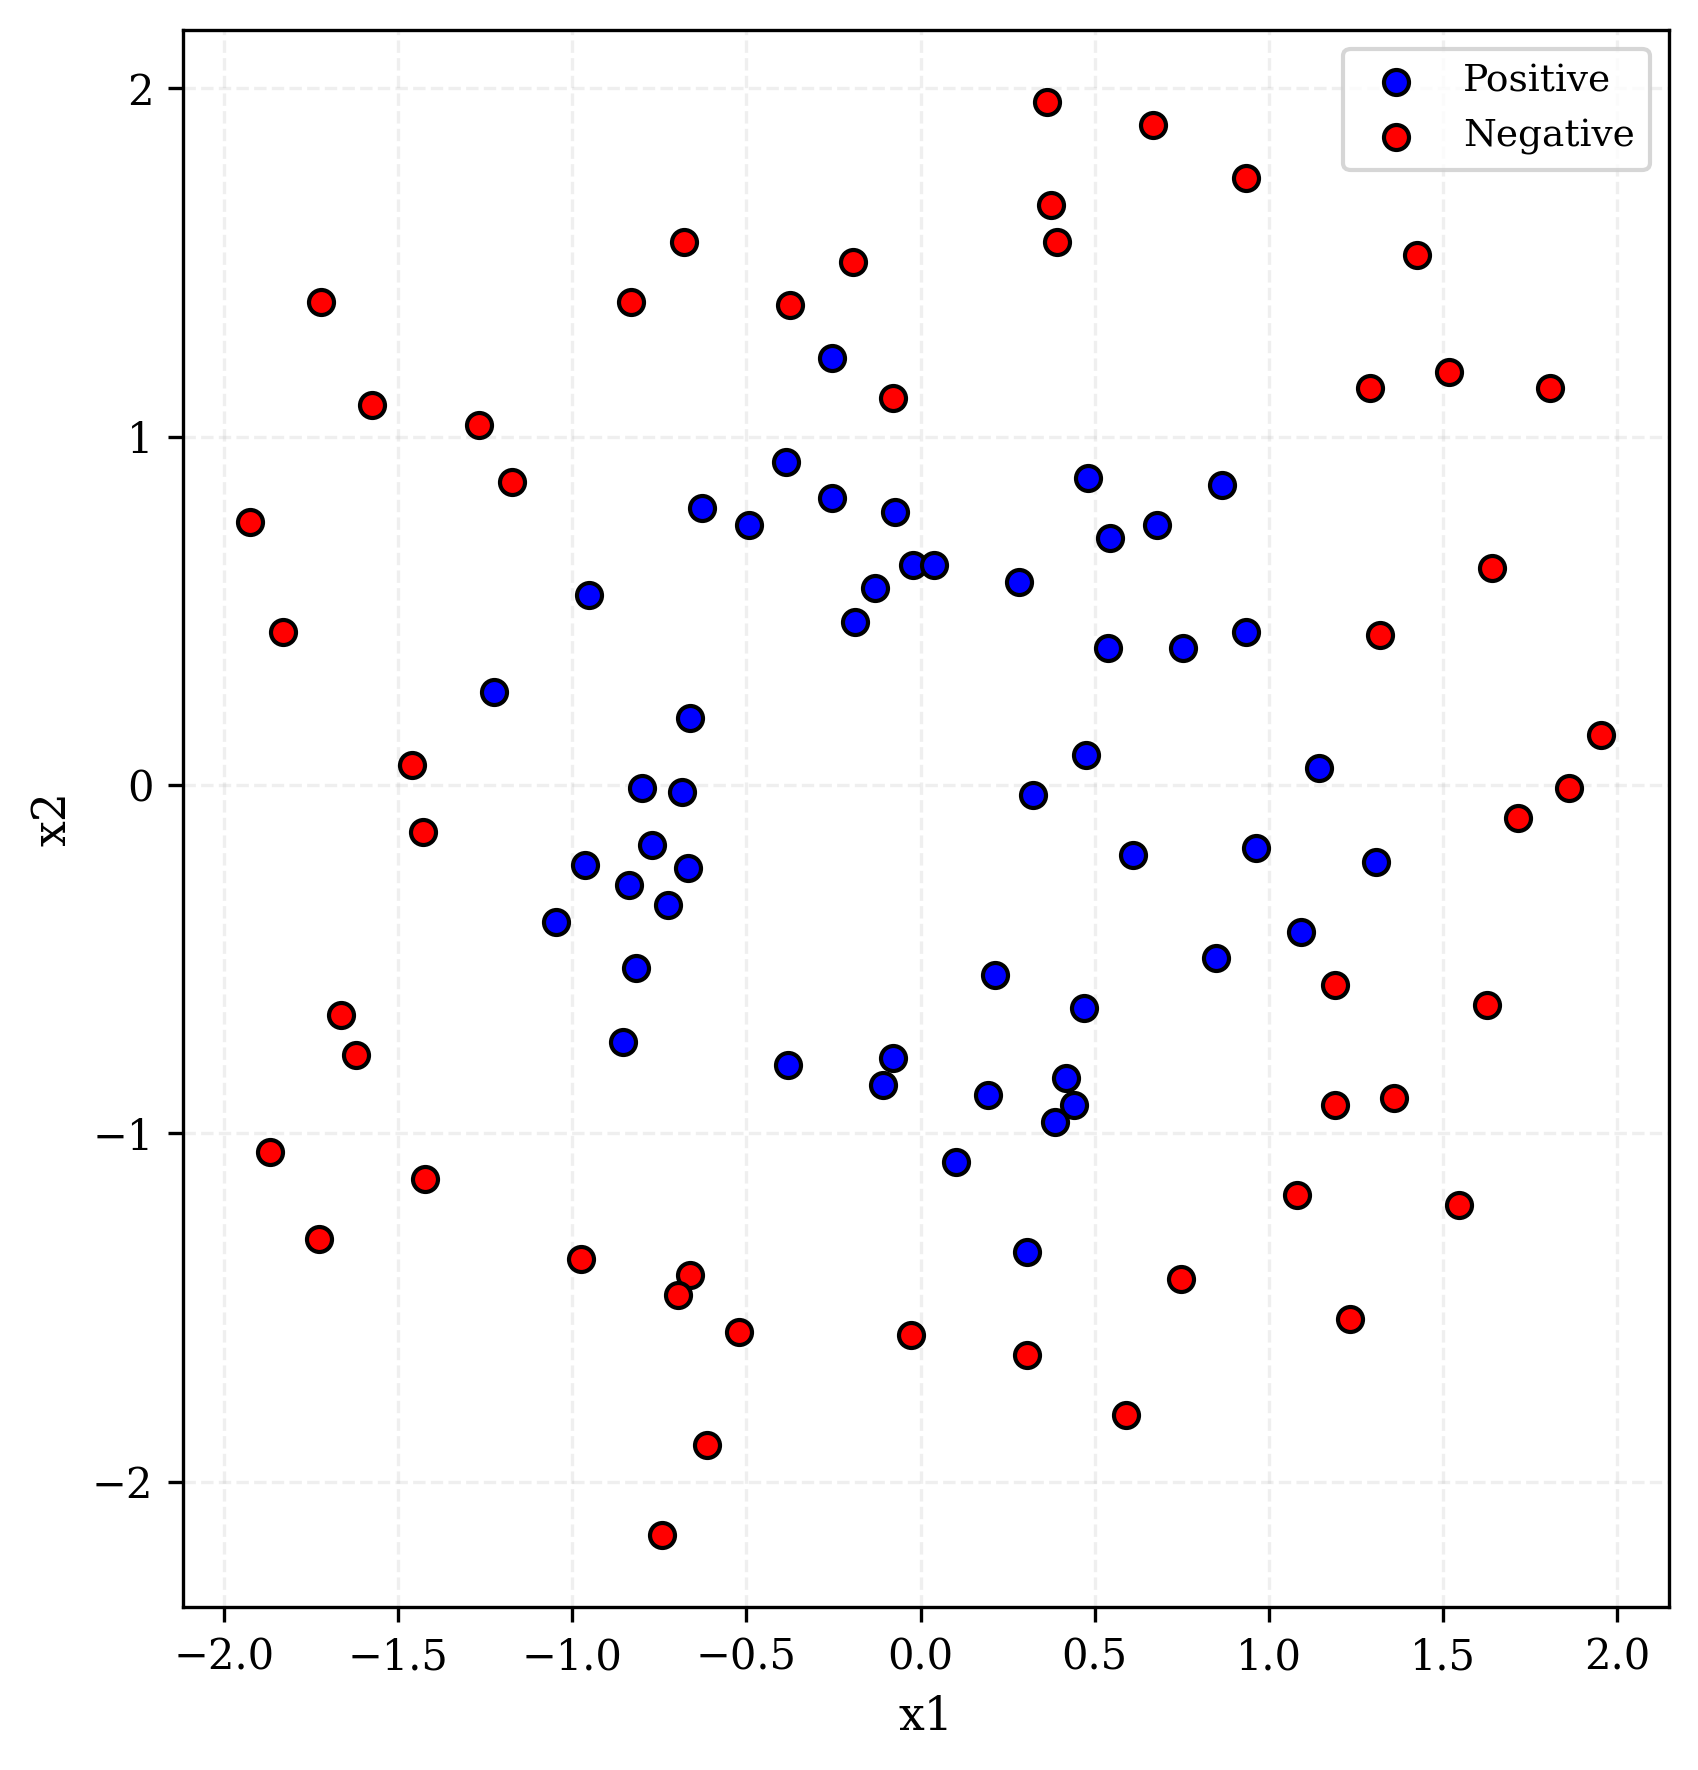

In [4]:
raw_data_fig, raw_data_ax = plot_in_rectangular_coordinates(dataset.X, dataset.y, title='')
raw_data_ax.set_aspect('equal')
display(raw_data_fig)

In [61]:
num_points1 = 100
num_points2 = 80
r_min = 0.0
r_cutoff = 1.0
delta_r_cutoff = 0.0
r_max = 2 * 1.0
overall_noise = 0.1

X1 = pd.DataFrame(
    generate_uniform_ring_points(
        num_points=num_points1, 
        r_min=r_min, r_max=r_cutoff, 
        noise_std=overall_noise,
        coord_system='polar'
        ), columns=['x1', 'x2']
)

X2 = pd.DataFrame(
    generate_uniform_ring_points(
        num_points=num_points2, 
        r_min=r_cutoff+delta_r_cutoff, r_max=r_max,
        noise_std=overall_noise, 
        coord_system='polar'
        ), columns=['x1', 'x2']
)

X = pd.concat([X1, X2])
y = np.concat([np.zeros(len(X1)), np.ones(len(X2))])

X_cart = pd.DataFrame(
    {
        'x1': X['x1'] * np.cos(X['x2']),
        'x2': X['x1'] * np.sin(X['x2'])
    }
)
X_cos2 = polar_to_curvilinear_cos2theta(X['x1'], X['x2'])

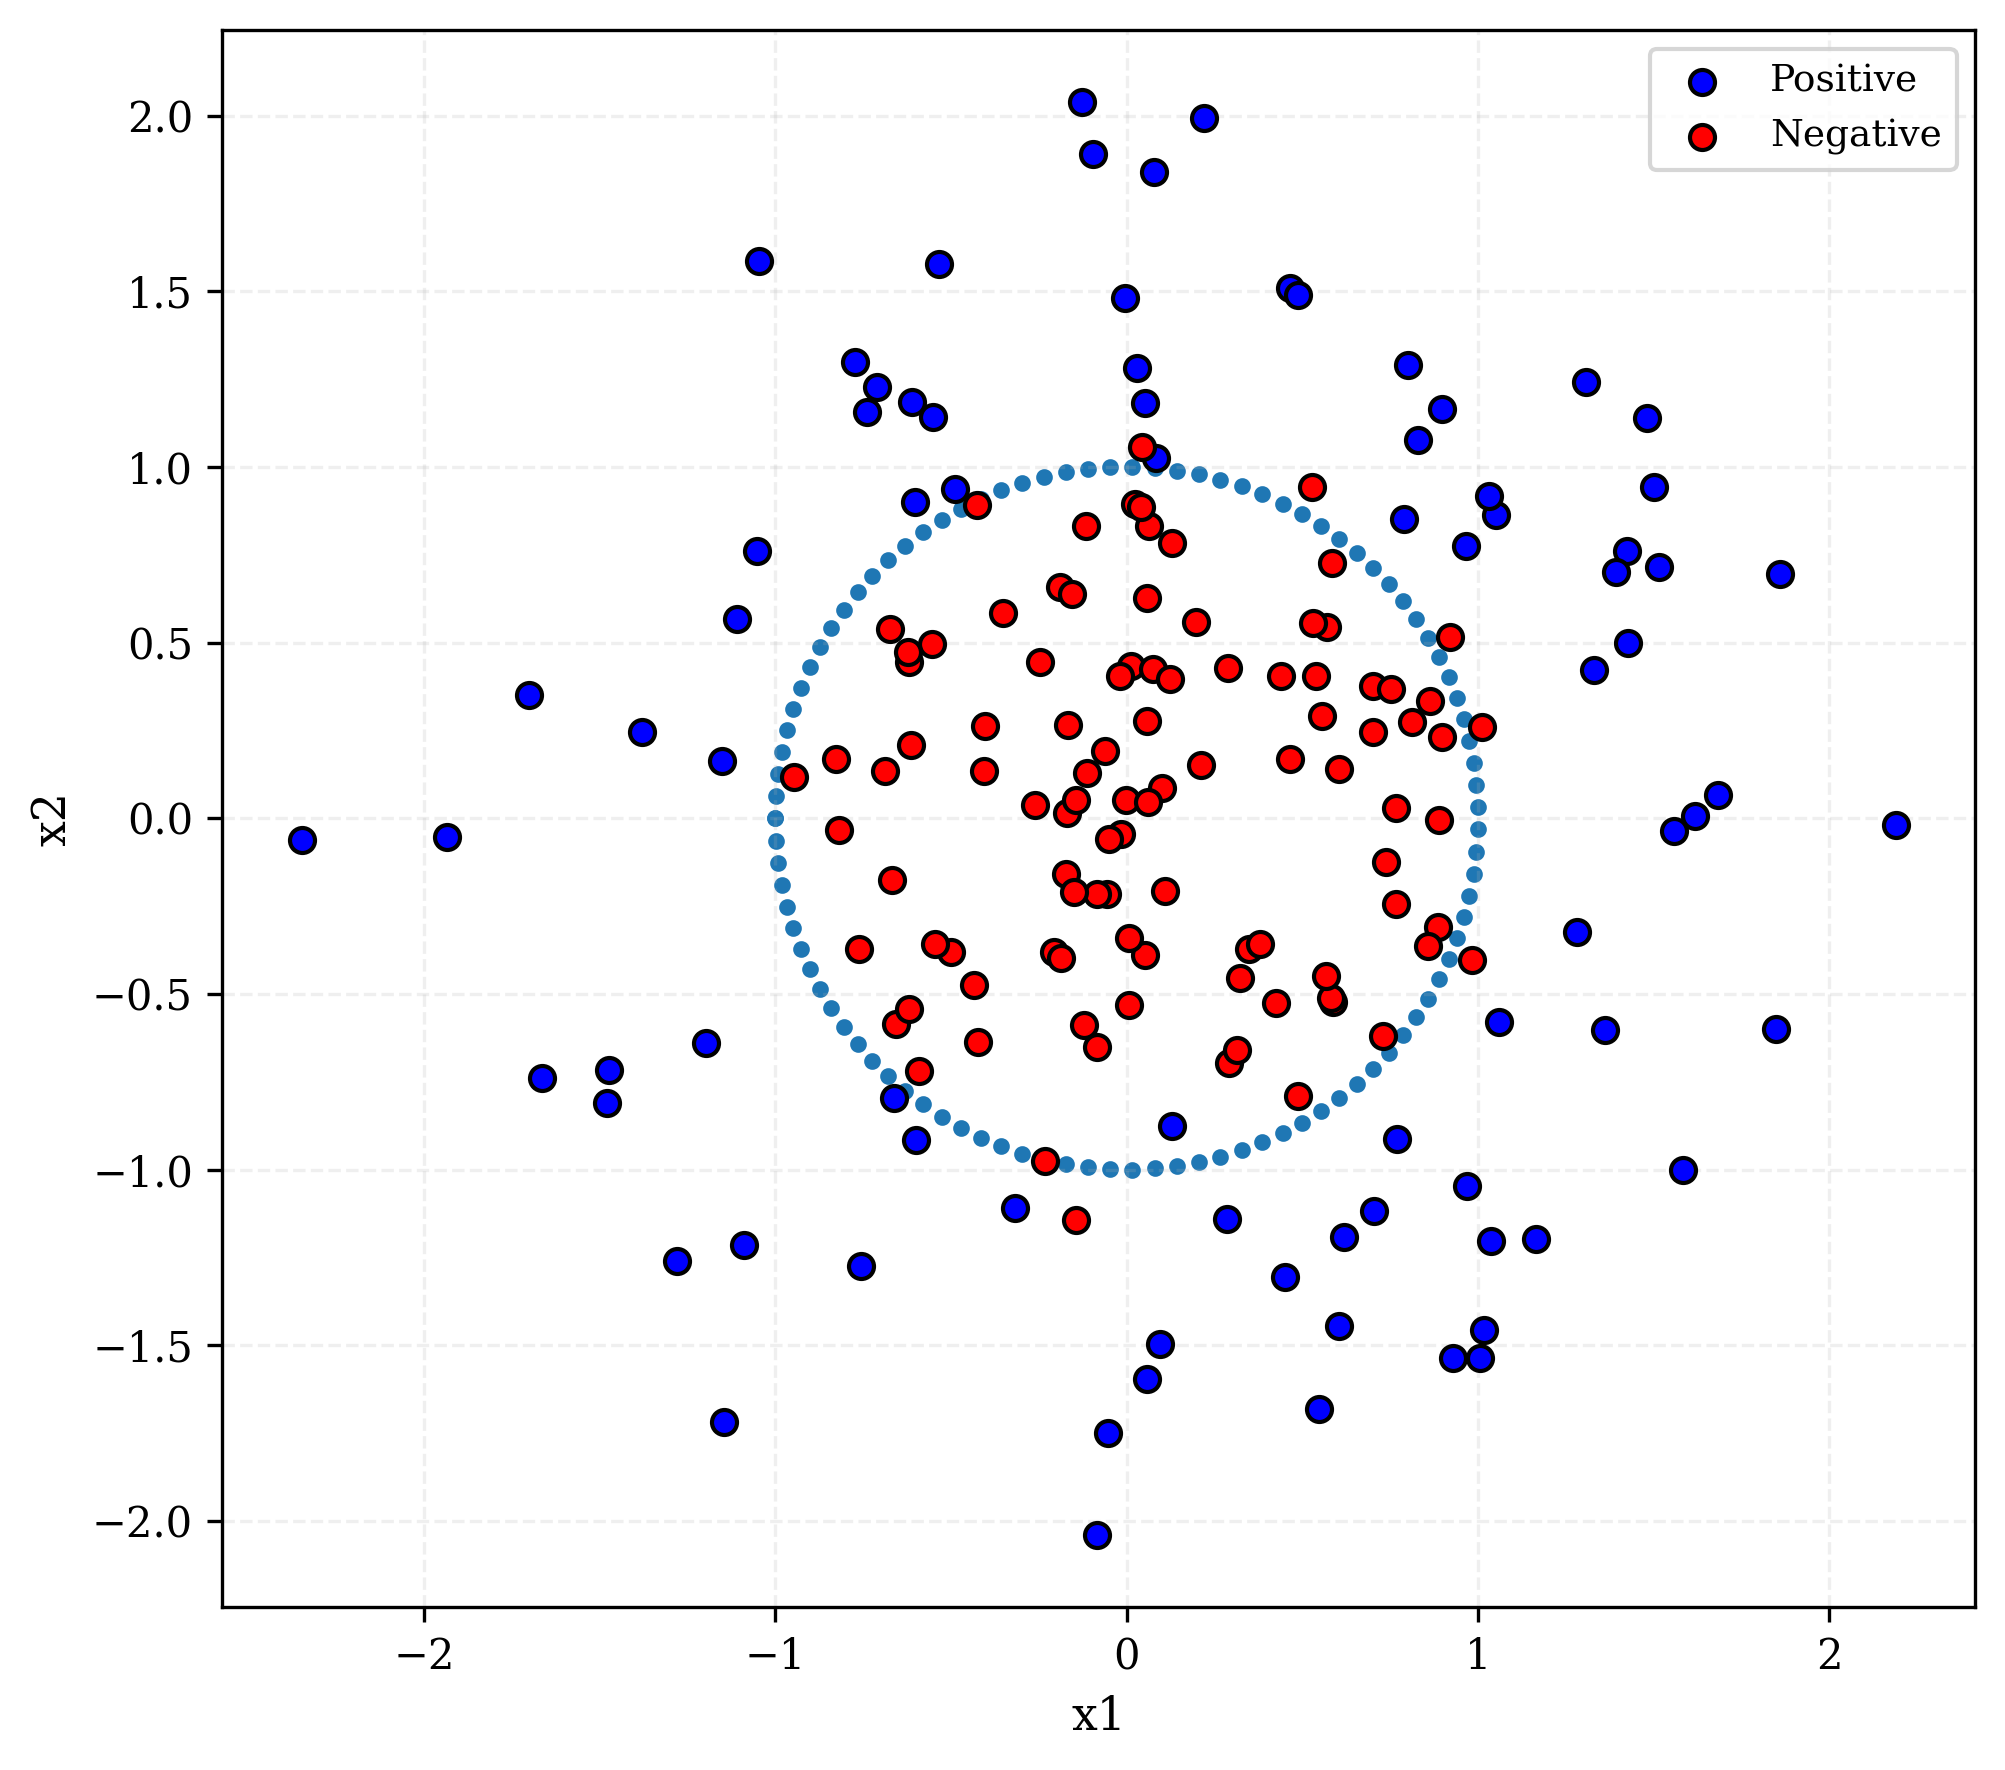

In [62]:
raw_data_fig, raw_data_ax = plot_in_rectangular_coordinates(X=X_cart, y=y, title='', axis_x='x1', axis_y='x2')
R = 1.0
Thetas = np.linspace(-np.pi, np.pi, 100)
raw_data_ax.scatter(R*np.cos(Thetas), R*np.sin(Thetas), marker='.')
raw_data_ax.set_aspect('equal')
display(raw_data_fig)

In [79]:
TP_ref = len(X[(X['x1']<=r_cutoff) & (y==0)])
TN_ref = len(X[(X['x1']>r_cutoff) & (y==1)])

reference_metrics = {
    'accuracy': (TP_ref + TN_ref)/(num_points1+num_points2),
    'precision': TP_ref/(TP_ref + (num_points2-TN_ref)),
    'recall': TP_ref/(num_points1)
}
reference_metrics['f1'] = 2 * (reference_metrics['precision'] * reference_metrics['recall']) / (reference_metrics['precision'] + reference_metrics['recall'])
reference_metrics

{'accuracy': 0.9555555555555556,
 'precision': 0.9893617021276596,
 'recall': 0.93,
 'f1': 0.9587628865979382}

In [85]:
# Create a Cartesian meshgrid to plot decision boundaries
grid_x, grid_y, grid_cartesian = create_meshgrid(X_cart)

# Transform meshgrid into polar grid
grid_polar = cartesian_to_polar(grid_x.ravel(), grid_y.ravel())

# Transform polar into curvilinear grid
grid_cos_sqd = pd.DataFrame({ 'x1': grid_polar['x1'], 'x2': np.cos(grid_polar['x2'])**2})

,accuracy,precision,recall,f1
0,0.961111,0.986667,0.925,0.954839


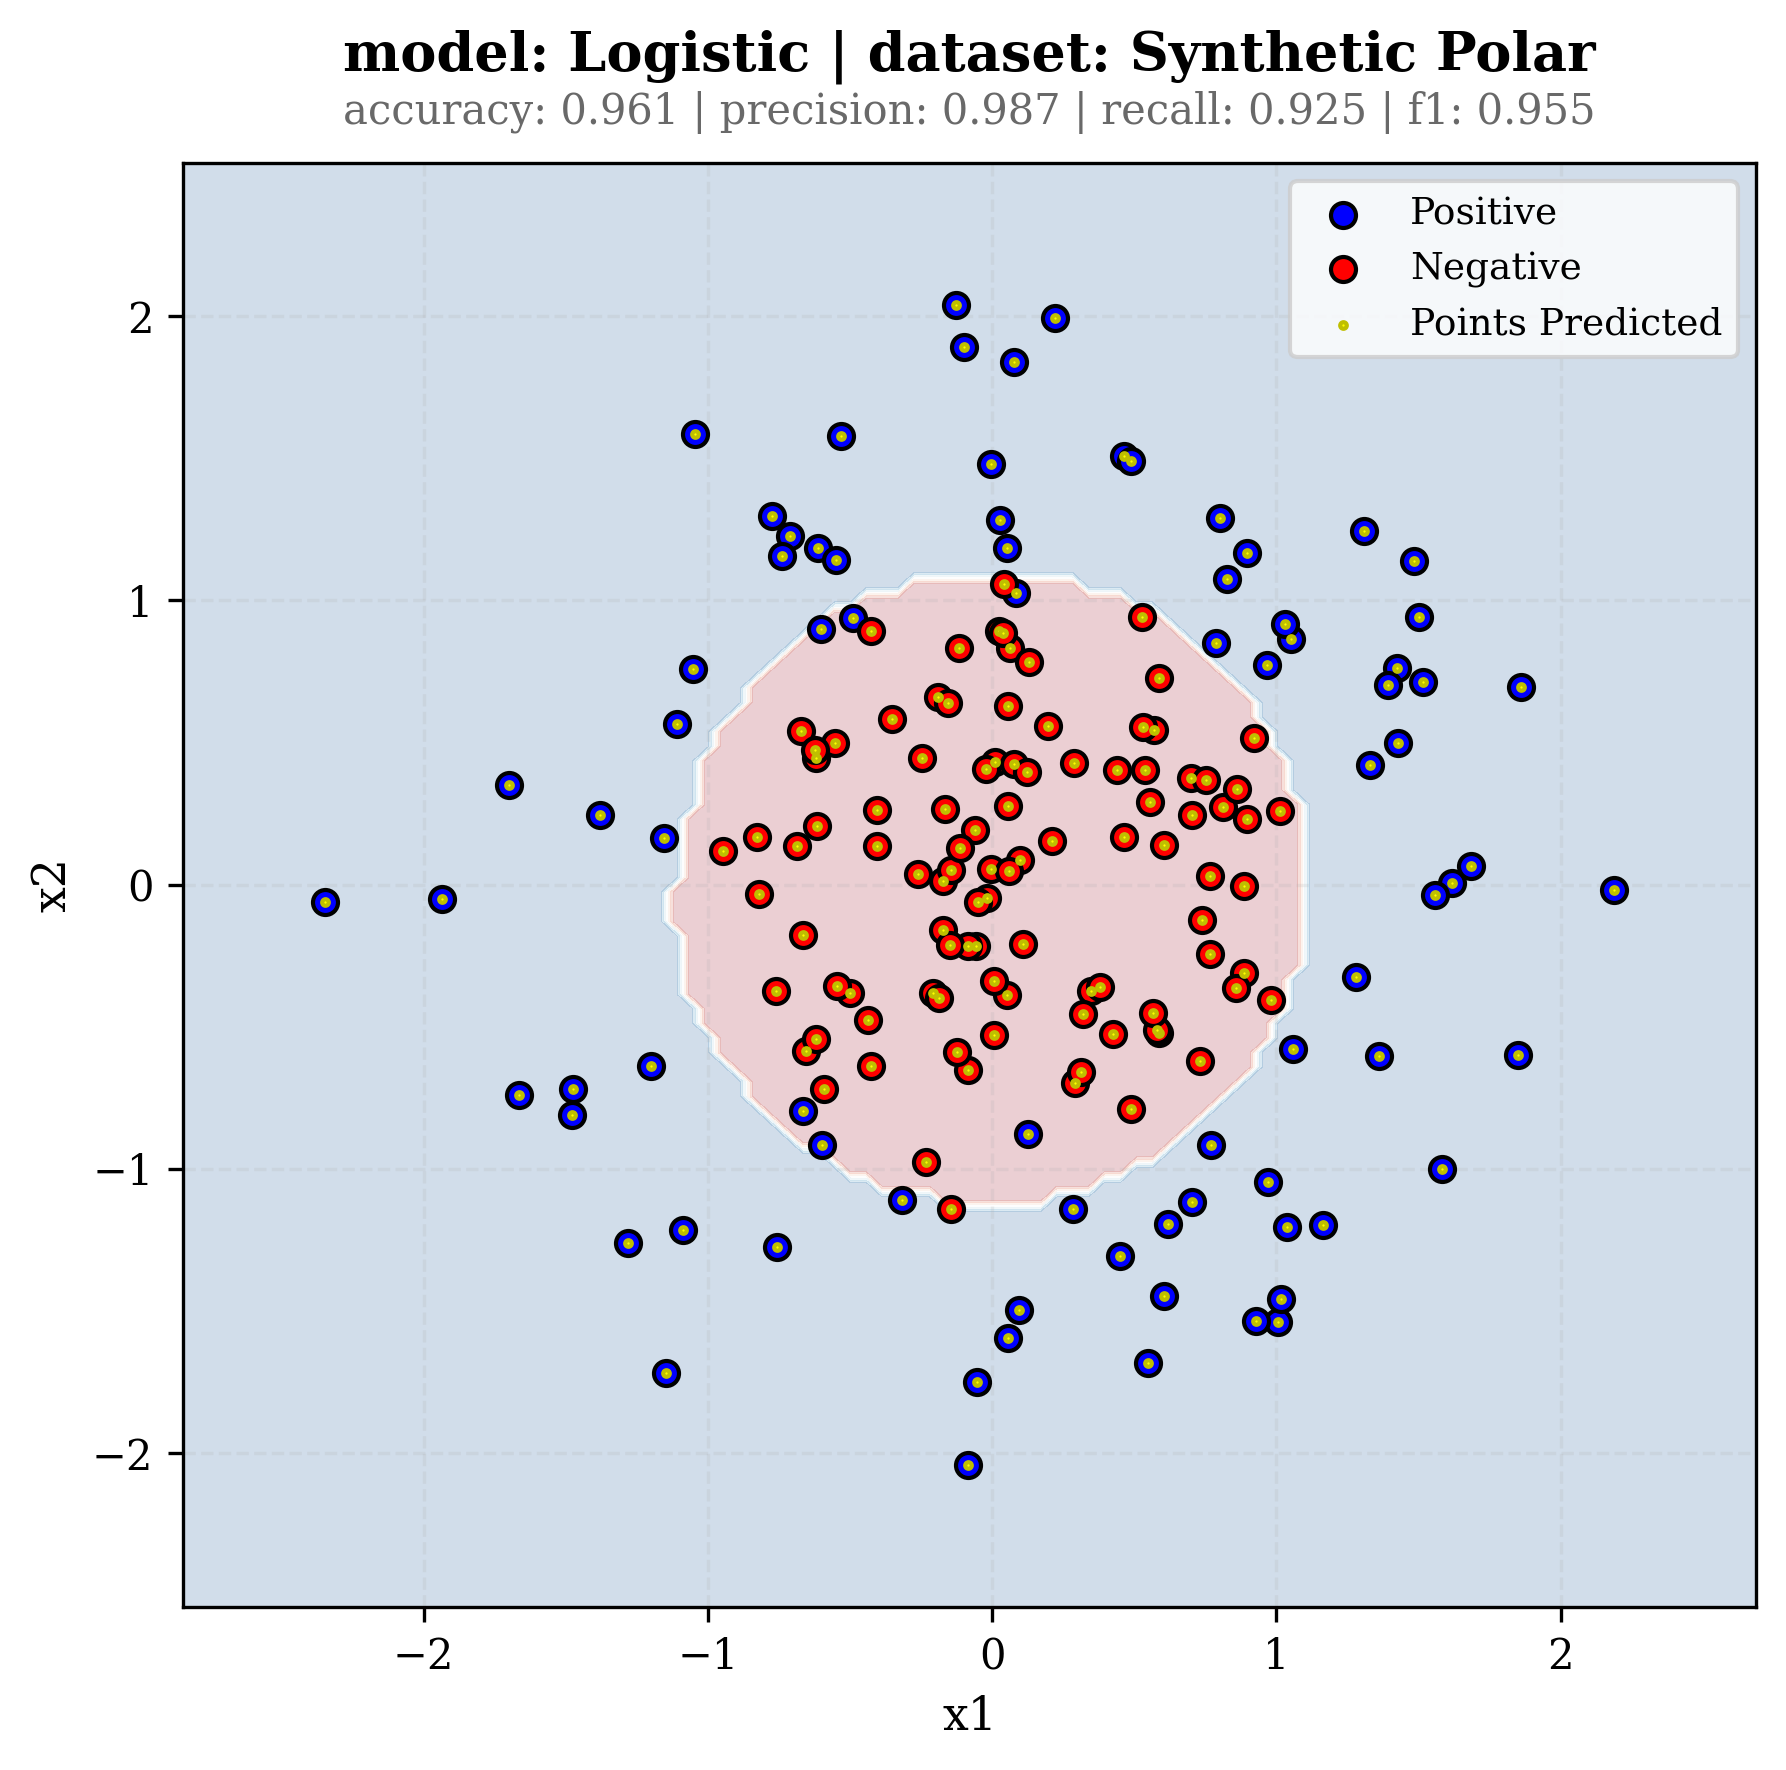

In [86]:
from src.visualization.decision_boundaries import plot_decision_boundary
from sklearn.linear_model import LogisticRegression
from src.evaluation.metrics import ModelMetrics

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X, y)
lr_metrics = ModelMetrics('Logistic Regression', 'Polar', y, lr_model.predict(X))
lr_metrics.compute_metrics()
display(lr_metrics.to_pandas())

lr_fig, lr_ax = plot_decision_boundary(
    model=lr_model, dataset_X=X_cart, dataset_y=y,
    prediction_domain=grid_polar, grid_x=grid_x, grid_y=grid_y,
    title=f'model: Logistic | dataset: Synthetic Polar',
    metrics=lr_metrics.to_dict()
)
lr_ax.set_aspect('equal')
display(lr_fig)

In [87]:
lr_metrics.to_dict()

{'accuracy': 0.9611111111111111,
 'precision': 0.9866666666666667,
 'recall': 0.925,
 'f1': 0.9548387096774194}

,accuracy,precision,recall,f1
0,0.961111,0.986667,0.925,0.954839


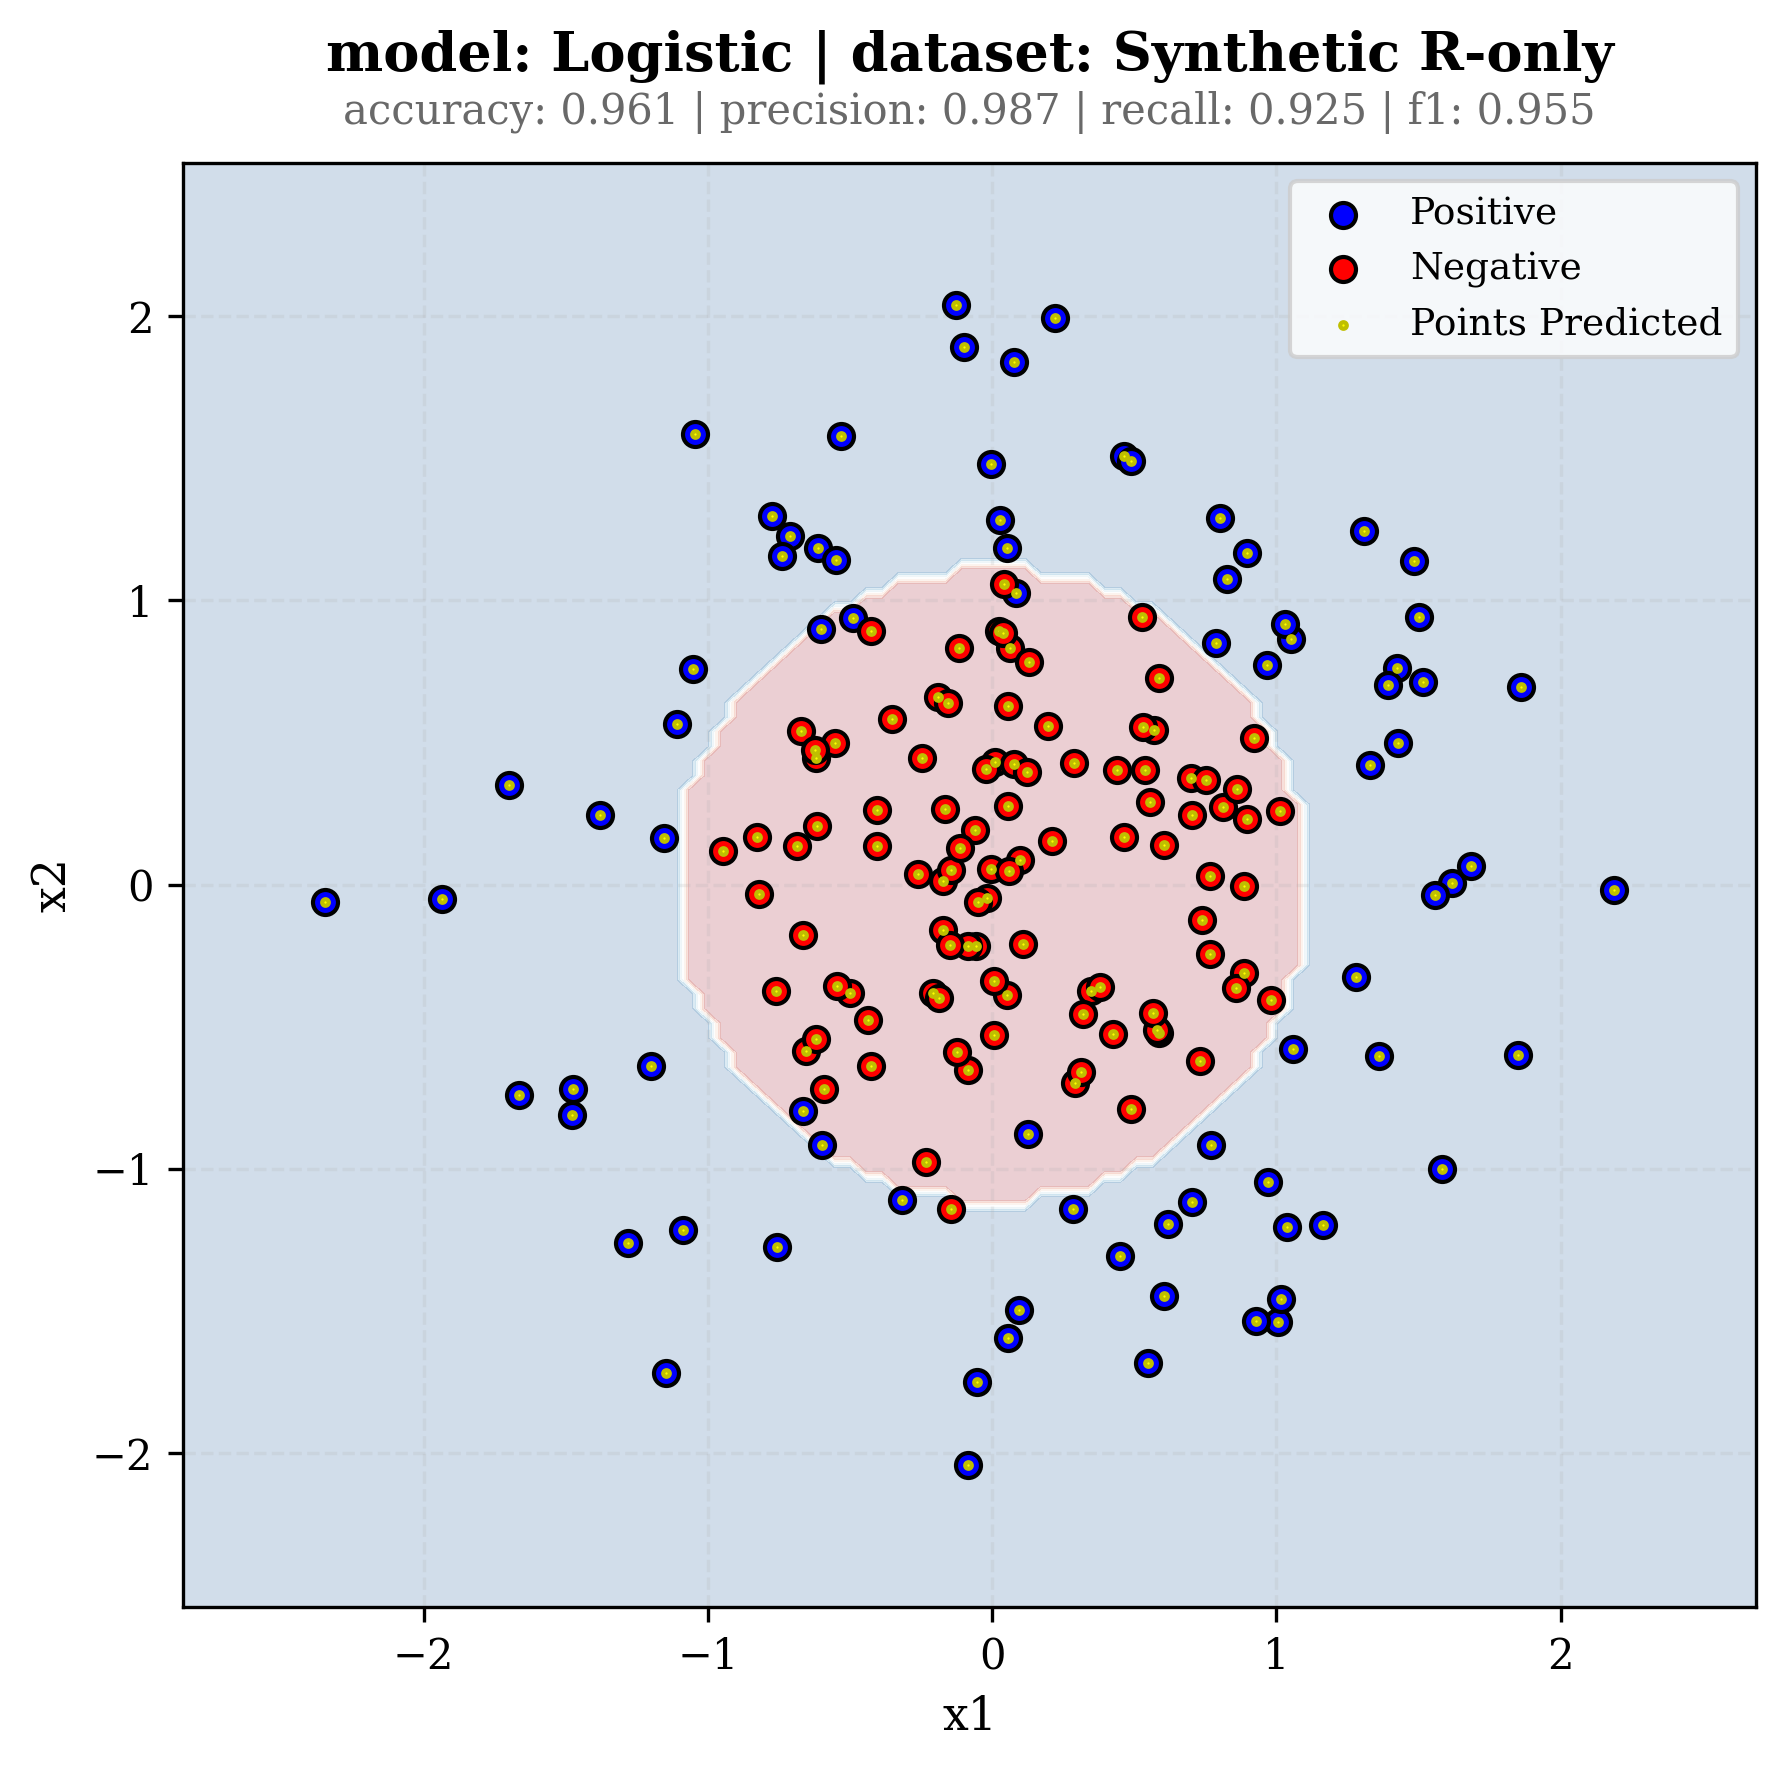

In [90]:
from sklearn.linear_model import LogisticRegression
from src.models.model_utilities import Model1DWrapper

lr_modelR = LogisticRegression(random_state=42)
lr_modelR.fit(X[['x1']], y)
lr_metricsR = ModelMetrics('Logistic Regression', 'R-only', y, lr_modelR.predict(X[['x1']]))
lr_metricsR.compute_metrics()
display(lr_metricsR.to_pandas())

wrapped_modelR = Model1DWrapper(trained_model=lr_modelR, vars_list=['x1'])

lr_R_fig, lr_R_ax = plot_decision_boundary(
    model=wrapped_modelR, dataset_X=X_cart, dataset_y=y,
    prediction_domain=grid_polar, grid_x=grid_x, grid_y=grid_y,
    title=f'model: Logistic | dataset: Synthetic R-only',
    metrics=lr_metricsR.to_dict()
)

lr_R_ax.set_aspect('equal')
display(lr_R_fig)

In [91]:
lr_metricsR.to_dict()

{'accuracy': 0.9611111111111111,
 'precision': 0.9866666666666667,
 'recall': 0.925,
 'f1': 0.9548387096774194}

,accuracy,precision,recall,f1
0,0.961111,0.986667,0.925,0.954839


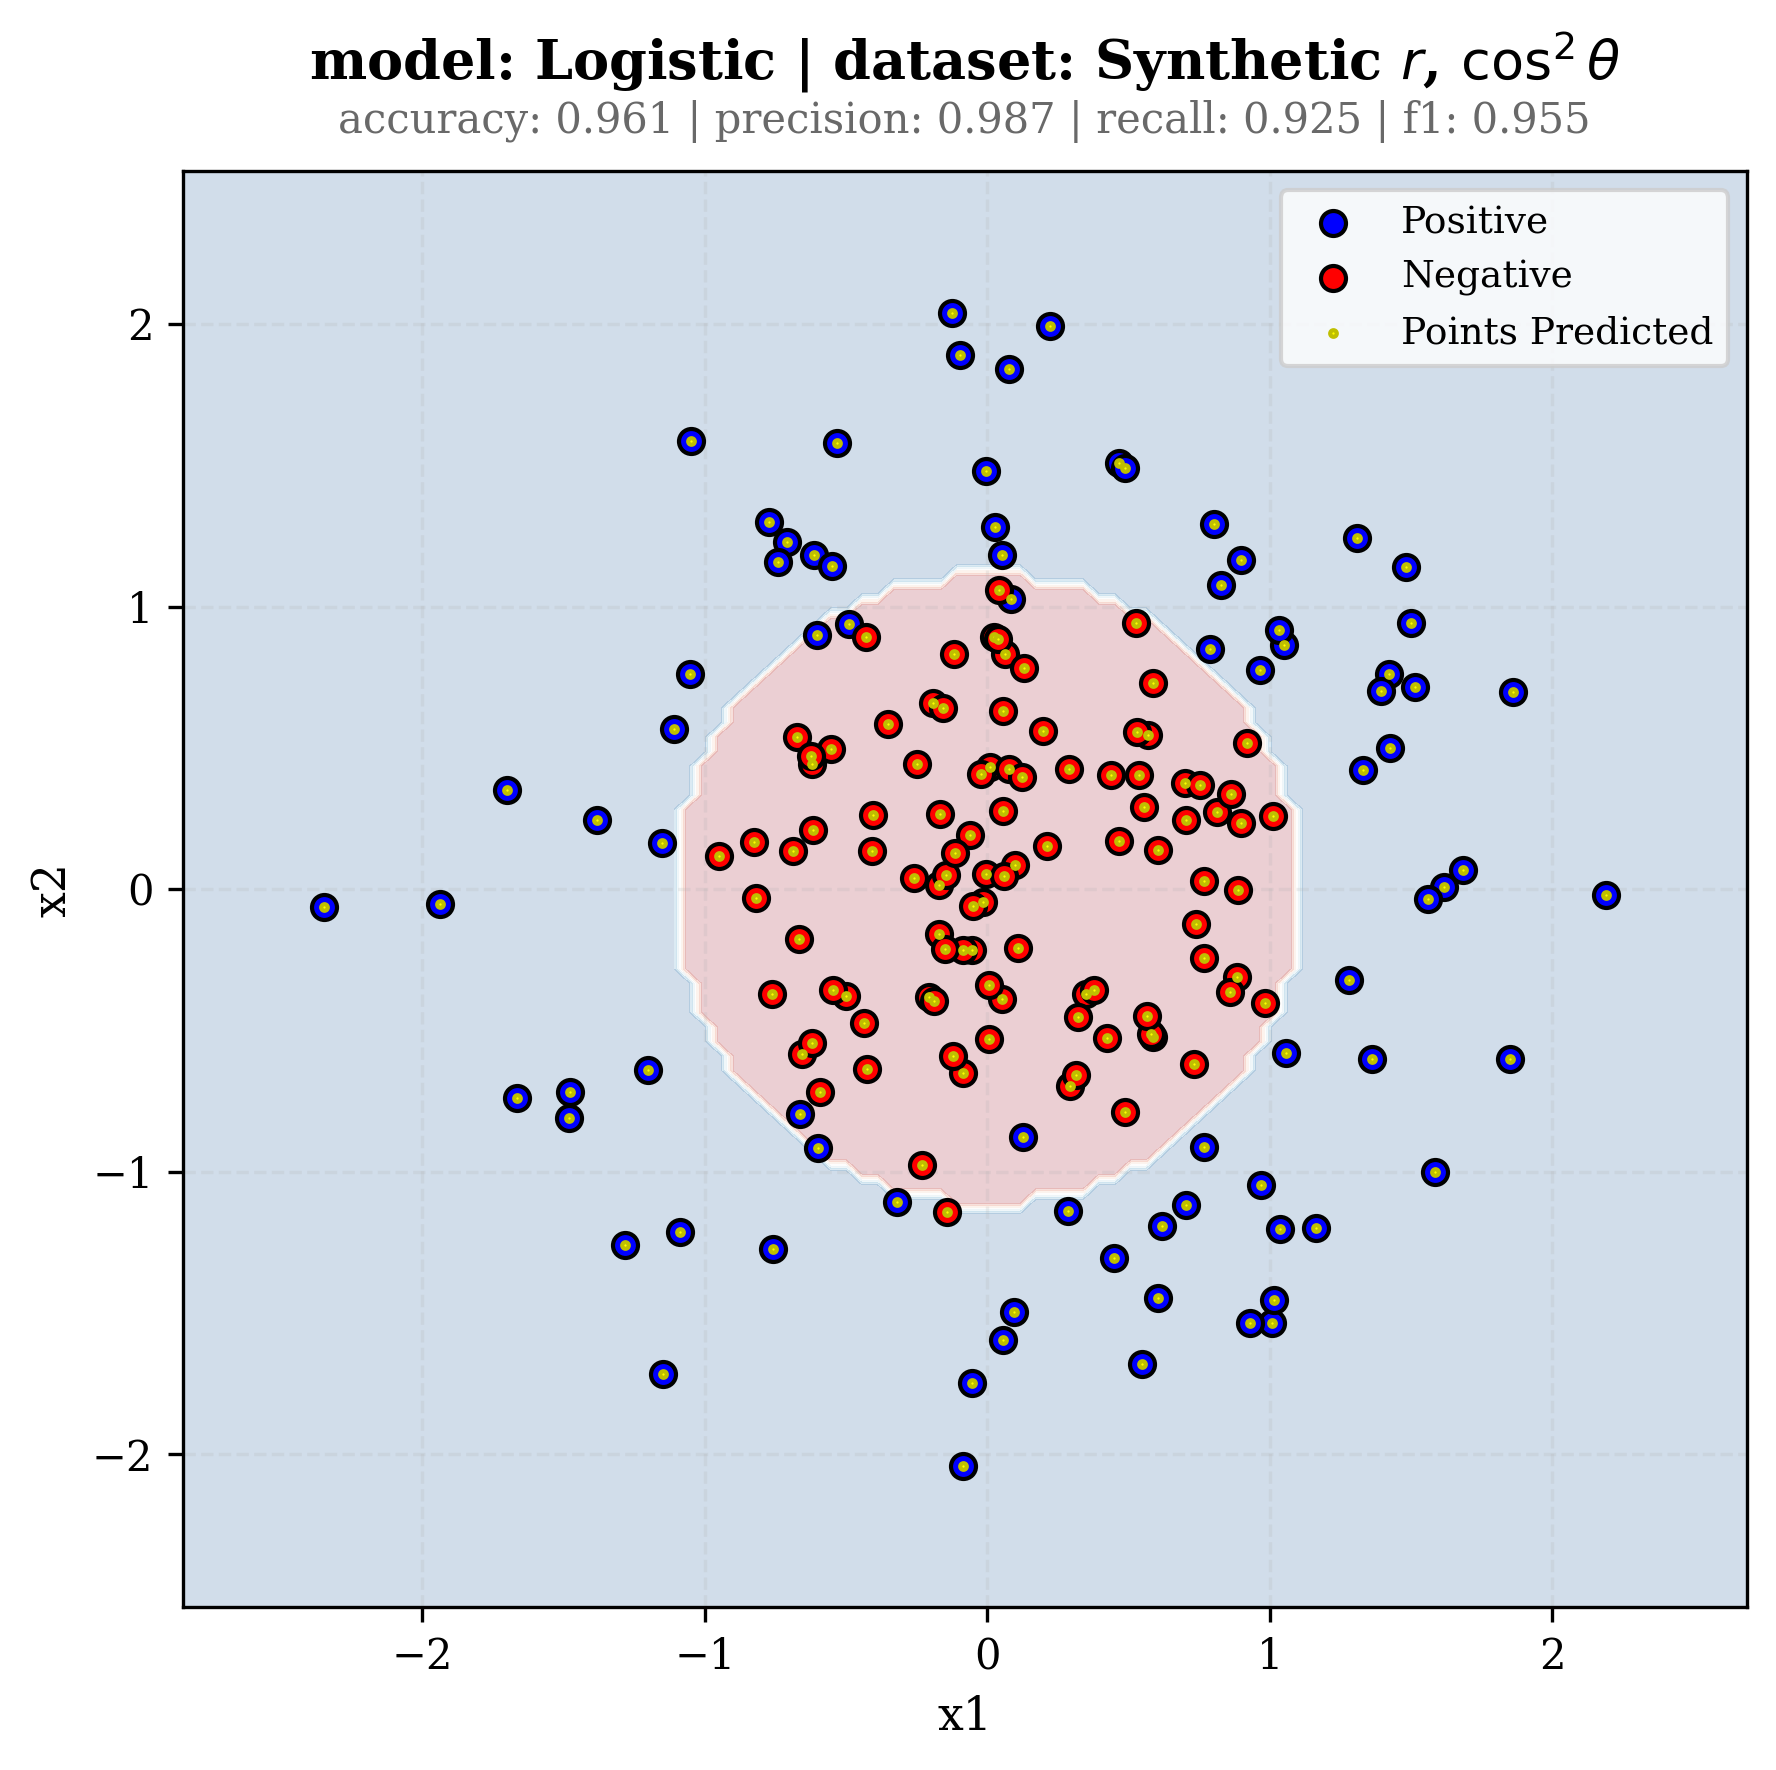

In [92]:
from src.visualization.decision_boundaries import plot_decision_boundary
from sklearn.linear_model import LogisticRegression
from src.evaluation.metrics import ModelMetrics

lr_model_cos2 = LogisticRegression(random_state=42)
lr_model_cos2.fit(X, y)
lr_metrics_cos2 = ModelMetrics('Logistic Regression', 'r,cos2()', y, lr_model_cos2.predict(X))
lr_metrics_cos2.compute_metrics()
display(lr_metrics_cos2.to_pandas())

dataset_label = r'$\cos^2{\theta}$'

lr_fig, lr_ax = plot_decision_boundary(
    model=lr_model_cos2, dataset_X=X_cart, dataset_y=y,
    prediction_domain=grid_cos_sqd, grid_x=grid_x, grid_y=grid_y,
    title=f'model: Logistic | dataset: Synthetic $r$, {dataset_label}',
    metrics=lr_metrics_cos2.to_dict()
)
lr_ax.set_aspect('equal')
display(lr_fig)

In [93]:
lr_metrics_cos2.to_dict()

{'accuracy': 0.9611111111111111,
 'precision': 0.9866666666666667,
 'recall': 0.925,
 'f1': 0.9548387096774194}

,accuracy,precision,recall,f1
0,0.977778,0.987179,0.9625,0.974684


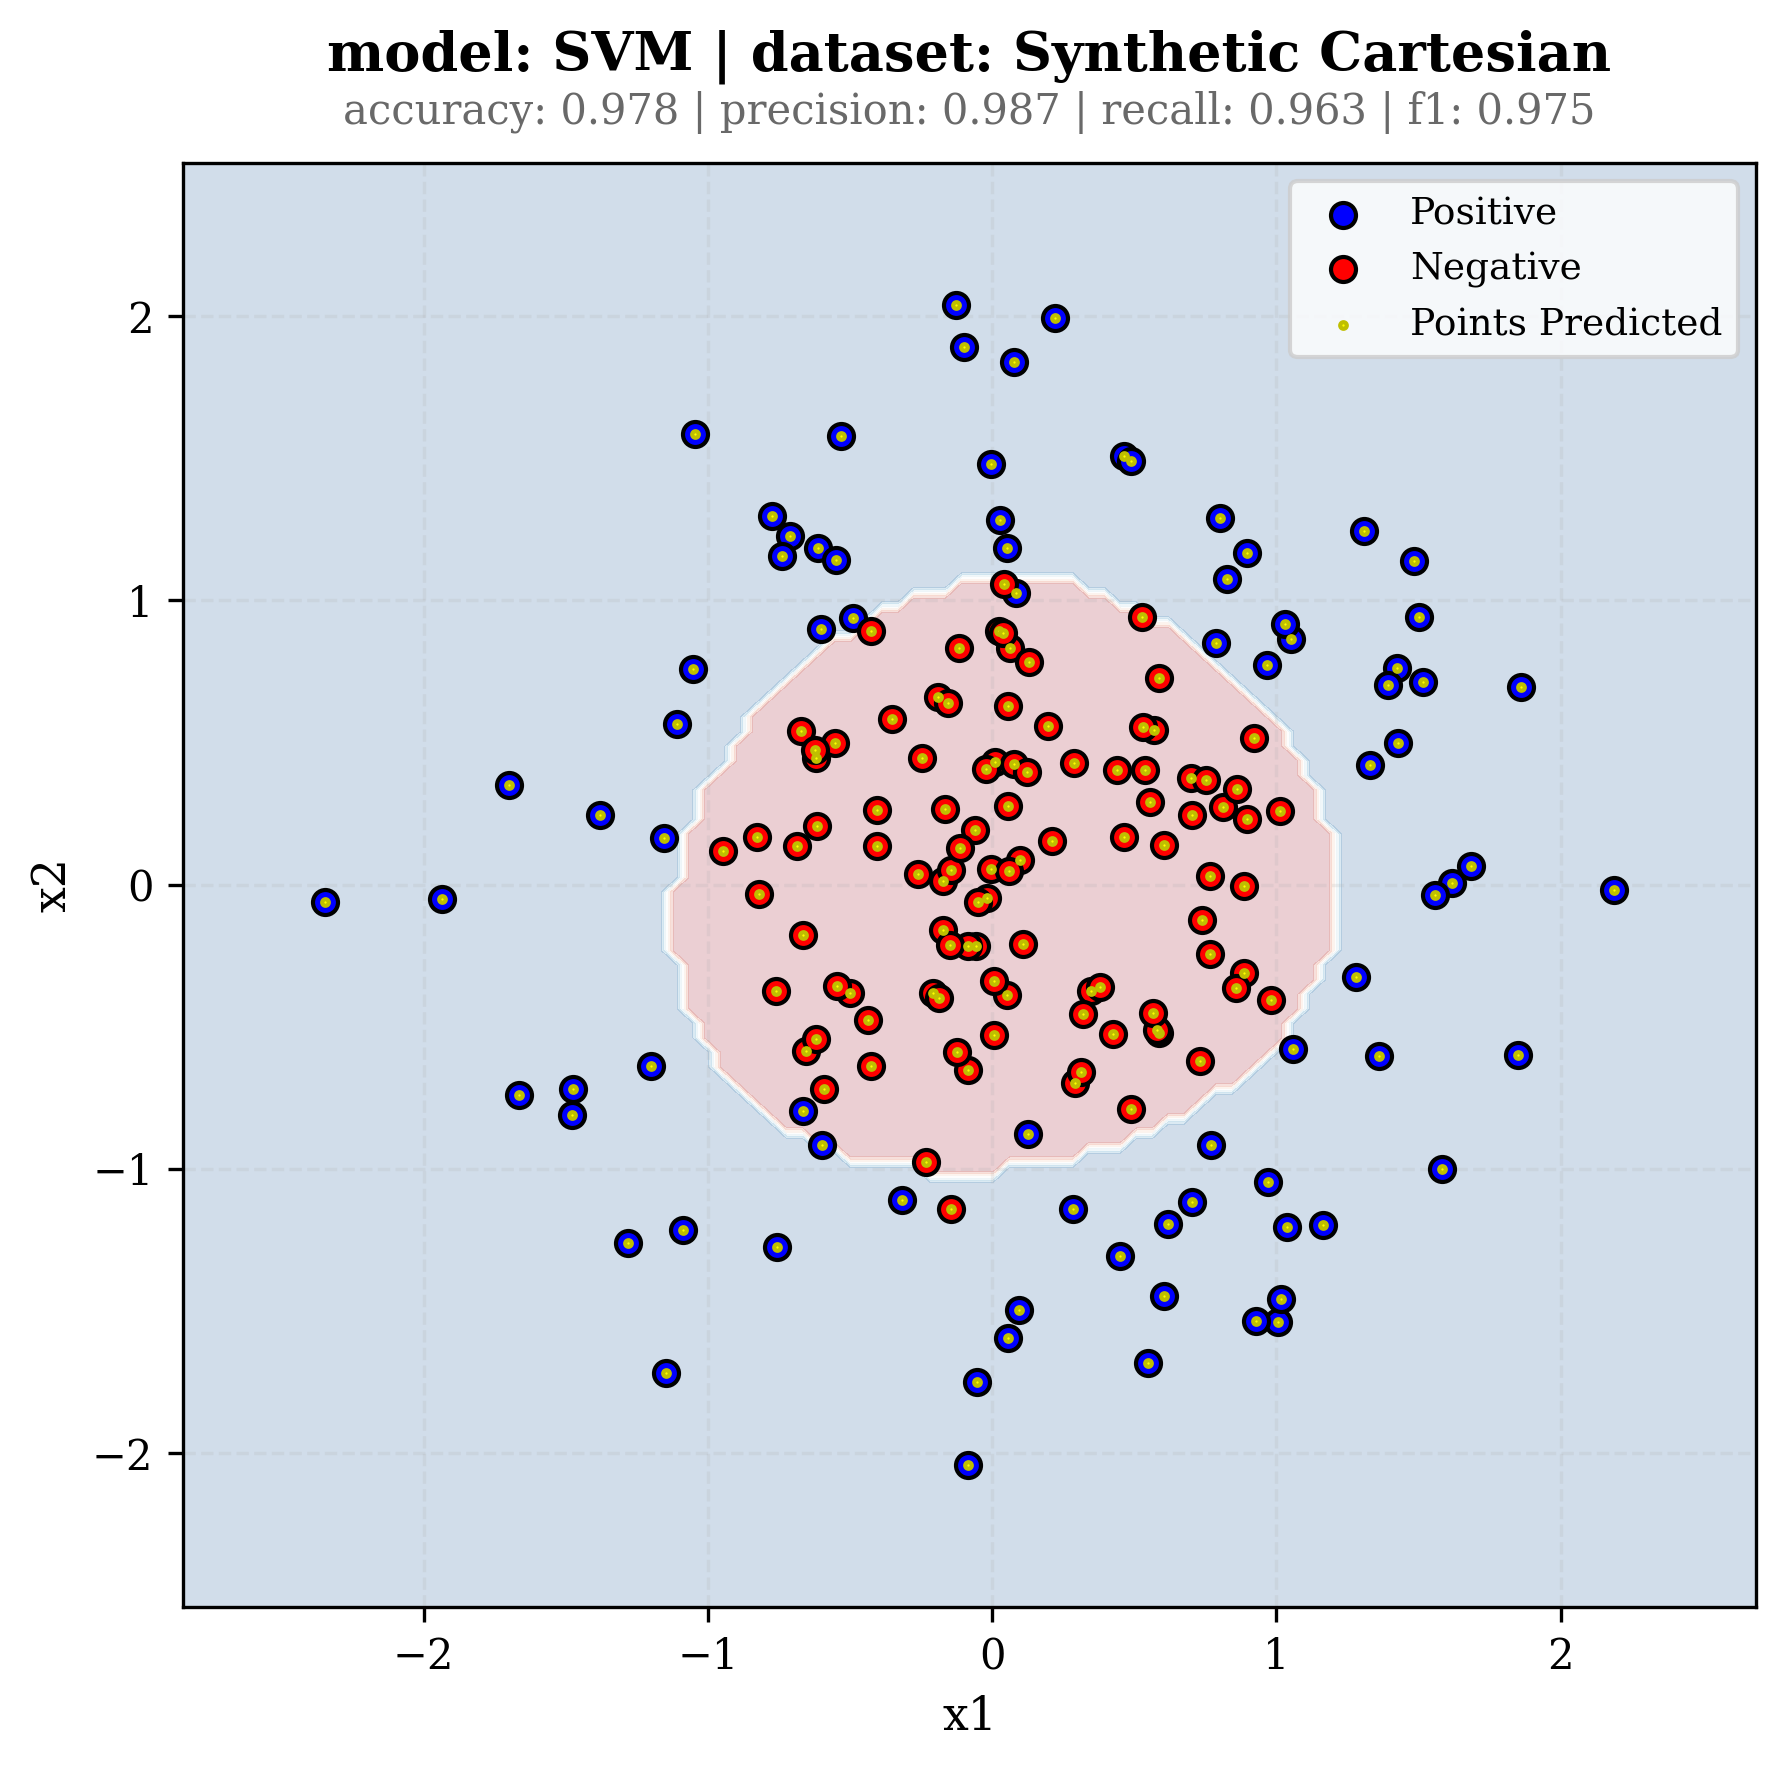

In [98]:
from src.visualization.decision_boundaries import plot_decision_boundary
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_cart, y)
svm_metrics = ModelMetrics('SVM', 'Cartesian', y, svm_model.predict(X_cart))
svm_metrics.compute_metrics()
display(svm_metrics.to_pandas())

fig, ax = plot_decision_boundary(
    model=svm_model, dataset_X=X_cart, dataset_y=y,
    prediction_domain=grid_cartesian, grid_x=grid_x, grid_y=grid_y,
    title=f'model: SVM | dataset: Synthetic Cartesian',
    metrics=svm_metrics.to_dict()
)
ax.set_aspect('equal')
display(fig)

In [95]:
svm_metrics.to_dict()

{'accuracy': 0.9777777777777777,
 'precision': 0.9871794871794872,
 'recall': 0.9625,
 'f1': 0.9746835443037974}

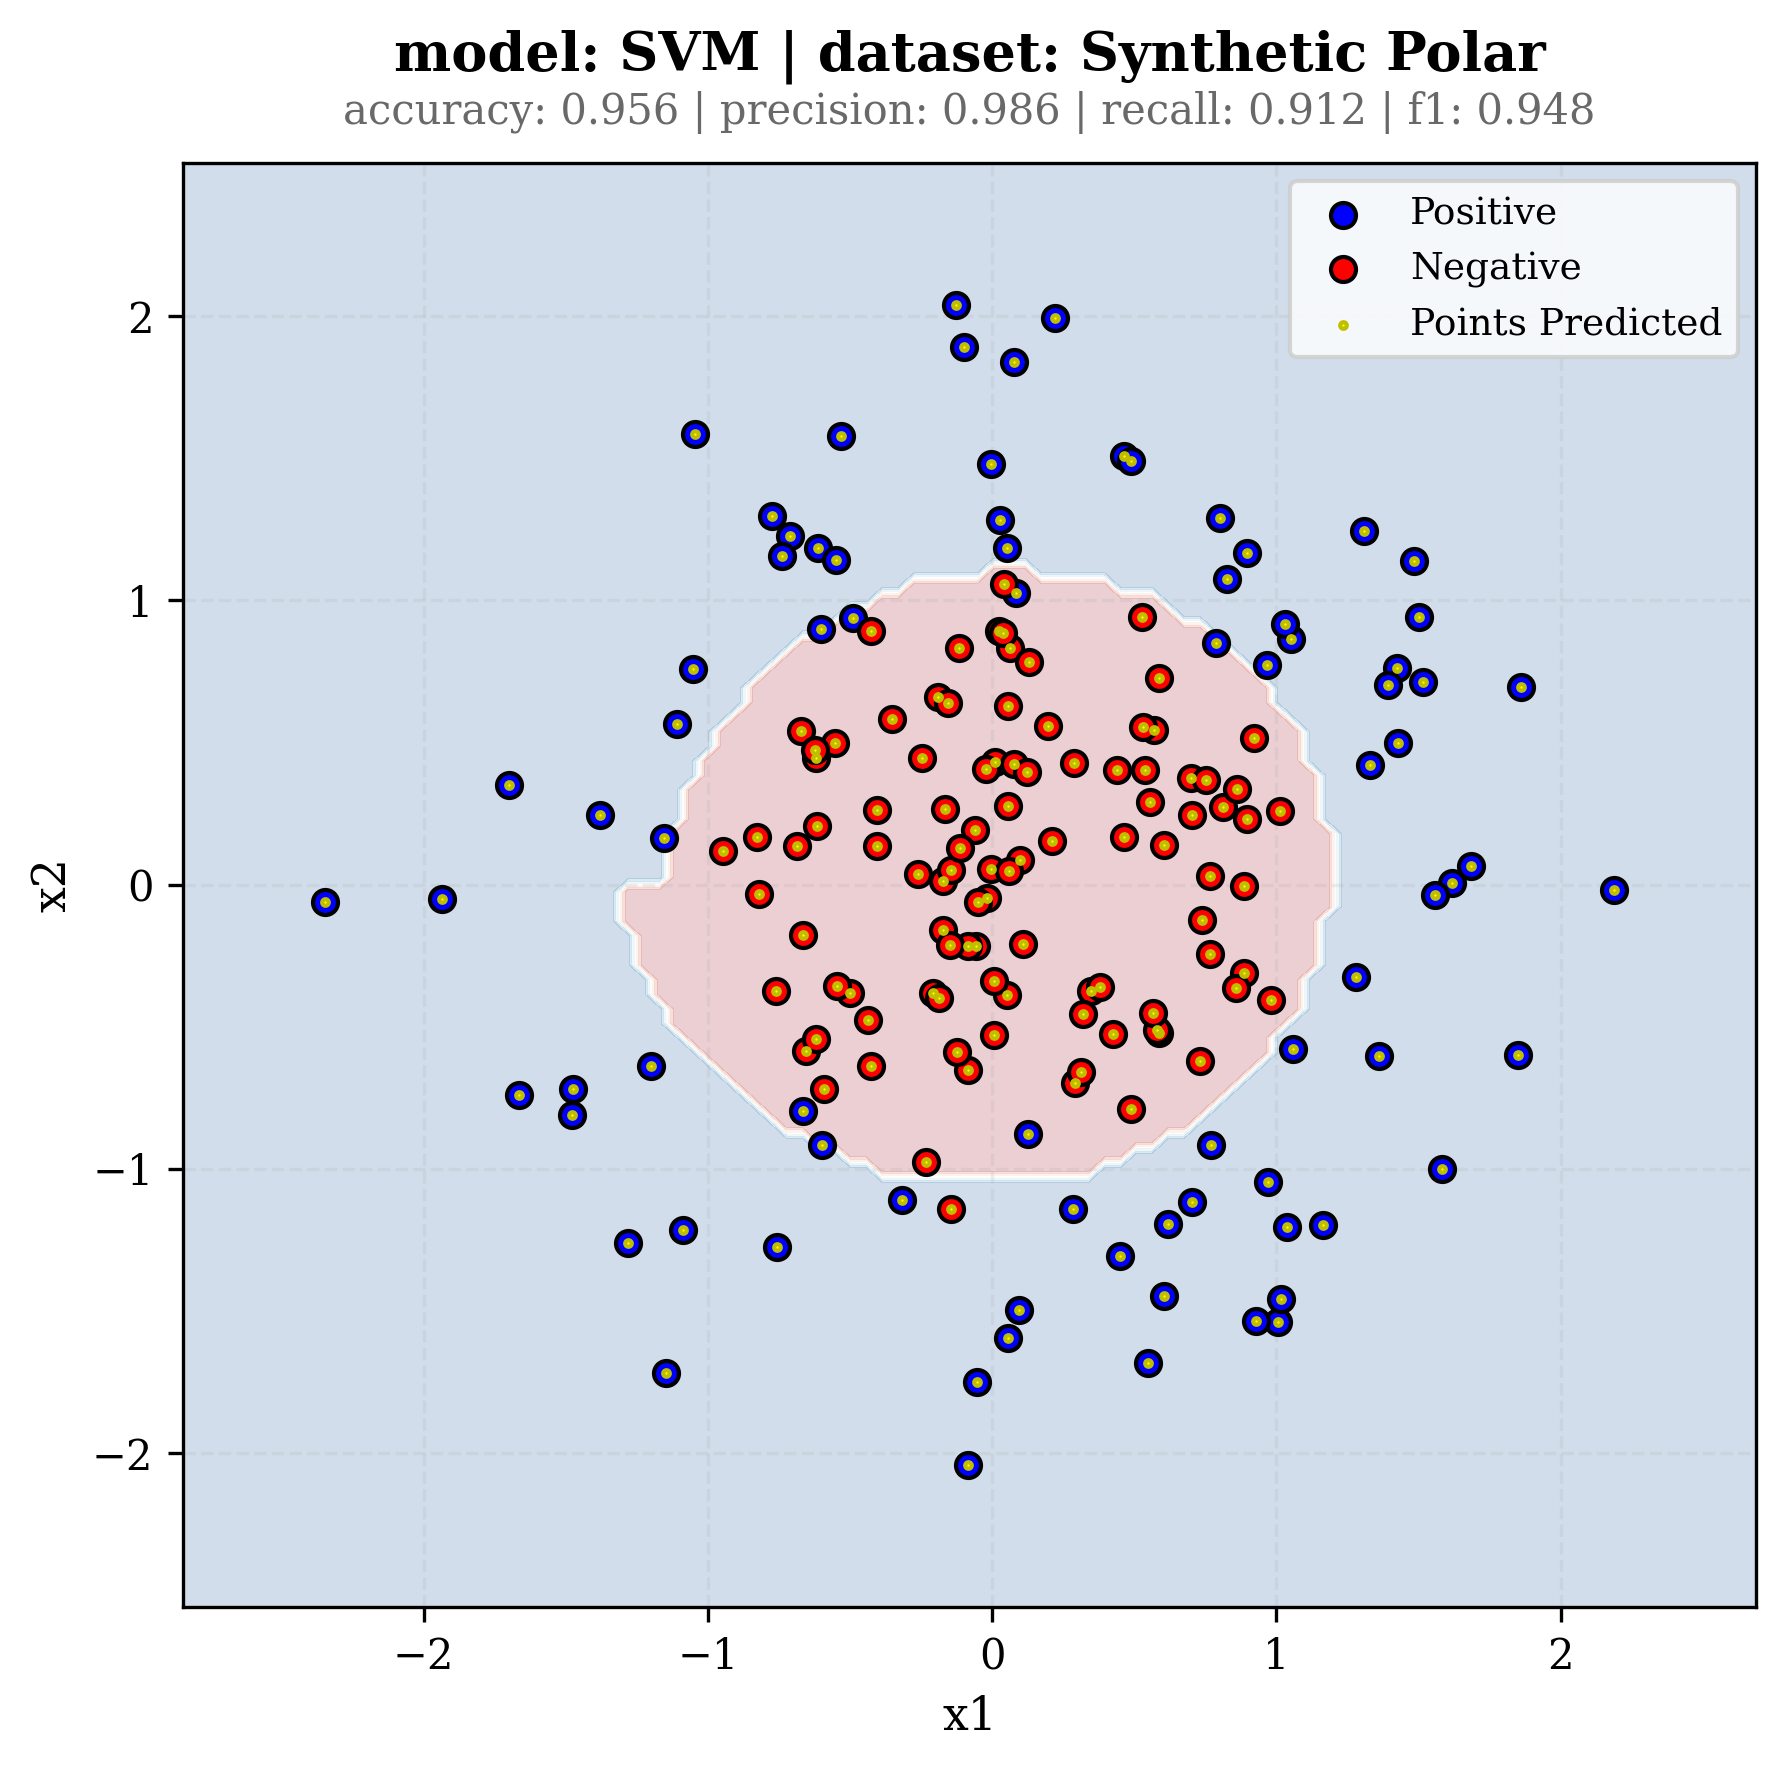

In [99]:
from src.visualization.decision_boundaries import plot_decision_boundary
from sklearn.svm import SVC

svm_polar_model = SVC(kernel='rbf', random_state=42)
svm_polar_model.fit(X, y)
svm_polar_metrics = ModelMetrics('SVM', 'Polar', y, svm_polar_model.predict(X))
svm_polar_metrics.compute_metrics()

fig, ax = plot_decision_boundary(
    model=svm_polar_model, dataset_X=X_cart, dataset_y=y,
    prediction_domain=grid_polar, grid_x=grid_x, grid_y=grid_y,
    title=f'model: SVM | dataset: Synthetic Polar',
    metrics=svm_polar_metrics.to_dict()
)
ax.set_aspect('equal')
display(fig)

In [100]:
svm_polar_metrics.to_dict()

{'accuracy': 0.9555555555555556,
 'precision': 0.9864864864864865,
 'recall': 0.9125,
 'f1': 0.948051948051948}

## Noise Experiments

In [101]:
from sklearn.model_selection import cross_validate

### Small Datasets

In [102]:
num_points1 = 100
num_points2 = 100
r_min = 0.0
r_cutoff = 1.0
delta_r_cutoff = 0.0
r_max = 2 * 1.0
overall_noise = 0.1

X1 = pd.DataFrame(
    generate_uniform_ring_points(
        num_points=num_points1, 
        r_min=r_min, r_max=r_cutoff, 
        noise_std=overall_noise,
        coord_system='polar'
        ), columns=['x1', 'x2']
)

X2 = pd.DataFrame(
    generate_uniform_ring_points(
        num_points=num_points2, 
        r_min=r_cutoff+delta_r_cutoff, r_max=r_max,
        noise_std=overall_noise, 
        coord_system='polar'
        ), columns=['x1', 'x2']
)

X = pd.concat([X1, X2])
y = np.concat([np.zeros(len(X1)), np.ones(len(X2))])

X_cart = pd.DataFrame(
    {
        'x1': X['x1'] * np.cos(X['x2']),
        'x2': X['x1'] * np.sin(X['x2'])
    }
)
X_cos2 = polar_to_curvilinear_cos2theta(X['x1'], X['x2'])

In [103]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline

# Initialize with 5 folds
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

folds = list(skf.split(X_cart, y))

In [ ]:
logreg_polar_pipeline = Pipeline([
    ("logreg_polar", LogisticRegression())
])
scoring = ["accuracy", "precision", "recall", "f1"]
logreg_polar_results = cross_validate(
    logreg_polar_pipeline,
    X,
    y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

logreg_R_pipeline = Pipeline([
    ("logreg_R", LogisticRegression())
])
scoring = ["accuracy", "precision", "recall", "f1"]
logreg_R_results = cross_validate(
    logreg_R_pipeline,
    X[['x1']],
    y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

logreg_cos2_pipeline = Pipeline([
    ("logreg_cos2", LogisticRegression())
])
scoring = ["accuracy", "precision", "recall", "f1"]
logreg__cos2_results = cross_validate(
    logreg_cos2_pipeline,
    X_cos2,
    y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

svm_pipeline = Pipeline([
    ("svm", SVC(kernel="rbf"))
])
scoring = ["accuracy", "precision", "recall", "f1"]
svm_results = cross_validate(
    svm_pipeline,
    X_cart,
    y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

In [107]:
svm_pipeline = Pipeline([
    ("svm", SVC(kernel="rbf"))
])

scoring = ["accuracy", "precision", "recall", "f1"]

svm_results = cross_validate(
    svm_pipeline,
    X_cart,
    y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

In [108]:
svm_polar_pipeline = Pipeline([
    ("svm", SVC(kernel="rbf"))
])

scoring = ["accuracy", "precision", "recall", "f1"]

svm_polar_results = cross_validate(
    svm_polar_pipeline,
    X,
    y,
    cv=folds,
    scoring=scoring,
    return_train_score=True
)

### Cross Validation Results

In [114]:
models_test = {}
models_train = {}

for key in svm_results.keys():
    svm_metrics = svm_results[key]
    svm_polar_metrics = svm_polar_results[key]
    logreg_metrics = logreg_polar_results[key]
    logreg_R_metrics = logreg_R_results[key]
    logreg_cos2_metrics = logreg__cos2_results[key]

    if 'train' in key:
        models_train[key] = {}
        my_dict = models_train
    else:
        models_test[key] = {}
        my_dict = models_test

    my_dict[key] = [f'{np.mean(svm_metrics):.5f} +/- {np.std(svm_metrics):.5f}',
                    f'{np.mean(svm_polar_metrics):.5f} +/- {np.std(svm_polar_metrics):.5f}', 
                    f'{np.mean(logreg_metrics):.5f} +/- {np.std(logreg_metrics):.5f}', 
                    f'{np.mean(logreg_R_metrics):.5f} +/- {np.std(logreg_R_metrics):.5f}', 
                    f'{np.mean(logreg_cos2_metrics):.5f} +/- {np.std(logreg_cos2_metrics):.5f}']

model_names = ['SVM', 'SVM-polar', 'LogReg-Polar', 'LogReg-R-only', 'LogReg-cos2']

models_test_df = pd.DataFrame(models_test, index=model_names)
models_train_df = pd.DataFrame(models_train, index=model_names)

In [115]:
display(models_test_df)
display(models_train_df)

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1
SVM,0.00111 +/- 0.00039,0.00342 +/- 0.00123,0.93000 +/- 0.02915,0.95919 +/- 0.03661,0.90000 +/- 0.05477,0.92729 +/- 0.03231
SVM-polar,0.00099 +/- 0.00026,0.00274 +/- 0.00054,0.91500 +/- 0.03742,0.95023 +/- 0.05023,0.88000 +/- 0.07483,0.91088 +/- 0.04237
LogReg-Polar,0.00209 +/- 0.00167,0.00370 +/- 0.00192,0.93500 +/- 0.03742,0.95162 +/- 0.04995,0.92000 +/- 0.06000,0.93368 +/- 0.03804
LogReg-R-only,0.00193 +/- 0.00115,0.00366 +/- 0.00134,0.94500 +/- 0.03317,0.96889 +/- 0.02548,0.92000 +/- 0.06000,0.94273 +/- 0.03537
LogReg-cos2,0.00202 +/- 0.00138,0.00346 +/- 0.00133,0.94500 +/- 0.04301,0.96871 +/- 0.02582,0.92000 +/- 0.08124,0.94188 +/- 0.04699


,train_accuracy,train_precision,train_recall,train_f1
SVM,0.94125 +/- 0.01658,0.96086 +/- 0.01141,0.92000 +/- 0.02915,0.93977 +/- 0.01772
SVM-polar,0.93125 +/- 0.00884,0.96267 +/- 0.00913,0.89750 +/- 0.02151,0.92873 +/- 0.01000
LogReg-Polar,0.94750 +/- 0.00848,0.96616 +/- 0.00631,0.92750 +/- 0.01458,0.94638 +/- 0.00901
LogReg-R-only,0.94500 +/- 0.00829,0.96353 +/- 0.00527,0.92500 +/- 0.01369,0.94383 +/- 0.00879
LogReg-cos2,0.94750 +/- 0.00848,0.96859 +/- 0.00640,0.92500 +/- 0.01369,0.94625 +/- 0.00897


### Medium-Sized Datasets

In [118]:
num_points1 = 500
num_points2 = 500
r_min = 0.0
r_cutoff = 1.0
delta_r_cutoff = 0.0
r_max = 2 * 1.0
overall_noise = 0.1

X1 = pd.DataFrame(
    generate_uniform_ring_points(
        num_points=num_points1, 
        r_min=r_min, r_max=r_cutoff, 
        noise_std=overall_noise,
        coord_system='polar'
        ), columns=['x1', 'x2']
)

X2 = pd.DataFrame(
    generate_uniform_ring_points(
        num_points=num_points2, 
        r_min=r_cutoff+delta_r_cutoff, r_max=r_max,
        noise_std=overall_noise, 
        coord_system='polar'
        ), columns=['x1', 'x2']
)

X = pd.concat([X1, X2])
y = np.concat([np.zeros(len(X1)), np.ones(len(X2))])

X_cart = pd.DataFrame(
    {
        'x1': X['x1'] * np.cos(X['x2']),
        'x2': X['x1'] * np.sin(X['x2'])
    }
)
X_cos2 = polar_to_curvilinear_cos2theta(X['x1'], X['x2'])

In [119]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline

# Initialize with 5 folds
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

folds = list(skf.split(X_cart, y))